# Breast Cancer Wisconsin Diagnostic Dataset 
- ➡️This is a classic dataset for training and benchmarking machine learning algorithms.
- ➡️ Biopsy features for classification of 569 malignant (cancer) and benign (not cancer) breast masses.
- ➡️ Features were computationally extracted from digital images of fine needle aspirate biopsy slides. Features correspond to properties of cell nuclei, such as size, shape and regularity. The mean, standard error, and worst value of each of 10 nuclear parameters is reported for a total of 30 features.
 
Available: https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset?resource=download 

### Details
- y. The outcomes. A factor with two levels denoting whether a mass is malignant ("M") or benign ("B").
- x. The predictors. A matrix with the mean, standard error and worst value of each of 10 nuclear measurements on the slide, for 30 total features per biopsy:
    - radius. Nucleus radius (mean of distances from center to points on perimeter).
    - texture. Nucleus texture (standard deviation of grayscale values).
    - perimeter. Nucleus perimeter.
    - area. Nucleus area.
    - smoothness. Nucleus smoothness (local variation in radius lengths).
    -  compactness. Nucleus compactness (perimeter^2/area - 1).
    - concavity, Nucleus concavity (severity of concave portions of the contour).
    - concave_pts. Number of concave portions of the nucleus contour.
    - symmetry. Nucleus symmetry.
    - fractal_dim. Nucleus fractal dimension ("coastline approximation" -1).

|Column	| Description|
|---------|-------------|
|x.radius_mean	|Mean radius of the tumor cells|
|x.radius_mean	|Mean radius of the tumor cells
|x.texture_mean	|Mean texture of the tumor cells
|x.perimeter_mean	|Mean perimeter of the tumor cells
|x.area_mean	|Mean area of the tumor cells
|x.smoothness_mean	|Mean smoothness of the tumor cells
|x.compactness_mean	|Mean compactness of the tumor cells
|x.concavity_mean	|Mean concavity of the tumor cells
|x.concave_points_mean	|Mean number of concave portions of the contour of the tumor cells
|x.symmetry_mean	|Mean symmetry of the tumor cells
|x.fractal_dimension_mean	|Mean "coastline approximation" of the tumor cells
|x.radius_se	|Standard error of the radius of the tumor cells
|x.texture_se	|Standard error of the texture of the tumor cells
|x.perimeter_se	|Standard error of the perimeter of the tumor cells
|x.area_se	|Standard error of the area of the tumor cells
|x.smoothness_se	|Standard error of the smoothness of the tumor cells
|x.compactness_se	|Standard error of the compactness of the tumor cells
|x.concavity_se	|Standard error of the concavity of the tumor cells
|x.concave_points_se	|Standard error of the number of concave portions of the contour of the tumor cells
|x.symmetry_se	|Standard error of the symmetry of the tumor cells
|x.fractal_dimension_se	|Standard error of the "coastline approximation" of the tumor cells
|x.radius_worst	|Worst (largest) radius of the tumor cells
|x.texture_worst	|Worst (most severe) texture of the tumor cells
|x.perimeter_worst	|Worst (largest) perimeter of the tumor cells
|x.area_worst	|Worst (largest) area of the tumor cells
|x.smoothness_worst	|Worst (most severe) smoothness of the tumor cells
|x.compactness_worst	|Worst (most severe) compactness of the tumor cells
|x.concavity_worst	|Worst (most severe) concavity of the tumor cells
|x.concave_points_worst	|Worst (most severe) number of concave portions of the contour of the tumor cells
|x.symmetry_worst	|Worst (most severe) symmetry of the tumor cells
|x.fractal_dimension_worst	|Worst (most severe) "coastline approximation" of the tumor cells
|y	target

In [3]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns      
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### 1. Load the data

I created this Baseline Model using the original 30 columns of the dataset to establish a starting point. In Machine Learning, you need to see how the algorithm performs when you give it absolutely all the raw information. This is the only way I can measure if the data cleaning and Feature Selection I do later actually improve the model. If I don't test with the 30 variables first, I have no way to prove the mathematical value of my work in the next phases.

In [4]:
df = pd.read_csv('brca_clean.csv')

### 2. Define X (all 30 deatures) and y (target)

In [5]:
X_baseline = df.drop(columns=['y'])
y_baseline = df['y']

### 3. Train/Test Split (80% train and 20% test)

In [6]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=0)

### 4. Scale features

The KNN algorithm works by calculating distances between points. If I don't scale the data, a feature with very big numbers (like 'area') will dominate the model, and features with small numbers (like 'smoothness') will be ignored. StandardScaler makes all features fair and equal.
I chose StandardScaler over MinMaxScaler because of the nature of our medical data. During our EDA (Exploratory Data Analysis) phase, when reviewing the Boxplots, we discovered that we have very large extreme values (outliers). For example, features like area and concavity show some malignant tumors with exceptionally high values.
If I had used MinMaxScaler, those few giant values would have compressed all the data from the 'normal' cells into a tiny range just to make everything fit between 0 and 1. With the normal data so tightly squashed together, the KNN model would struggle to calculate distances and classify them correctly. StandardScaler handles these outliers much better (by using the mean and standard deviation) without destroying or squashing the rest of the information.


In [7]:
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

### 5. Initialize and train the Baseline KNN Model

In [8]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_b_scaled, y_train_b)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### 6. Make predictions and evaluate 

In [9]:
#Accuracy
y_pred_b = knn_baseline.predict(X_test_b_scaled)
baseline_accuracy = accuracy_score(y_test_b, y_pred_b)

In [10]:
print(f"--- BASELINE MODEL V1 (All 30 Features) ---")
print(f"Accuracy: {baseline_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL V1 (All 30 Features) ---
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        71
           1       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [11]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_baseline = confusion_matrix(y_test_b, y_pred_b)
print(cm_baseline)

[[71  0]
 [ 4 39]]


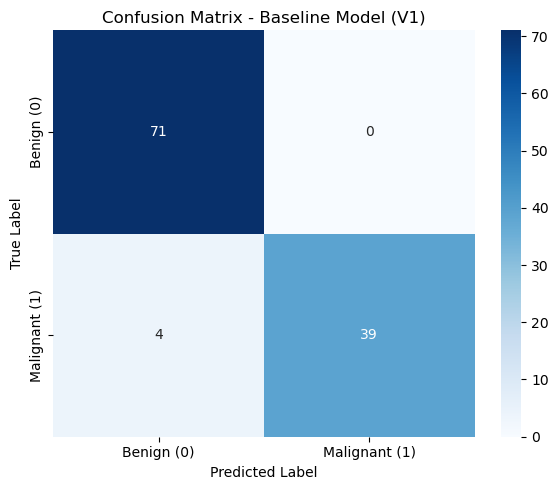

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malignant (1)'], 
            yticklabels=['Benign (0)', 'Malignant (1)'], ax=ax)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Baseline Model (V1)')
plt.tight_layout()

1. First Model (The Baseline)
First, I created a 'Baseline Model' using all 30 original columns. I wanted to see how the KNN algorithm works with the raw data before making any changes. This first model got an Accuracy of 96%. This is really high, which means the dataset is very good for predicting cancer right from the start.

2. Looking at the Confusion Matrix
But since this is a medical project, I can't just look at the overall accuracy. I need to check the Confusion Matrix. The worst mistake a model can make here is a False Negative (telling a sick person they don't have cancer). In my baseline model, I got 4 False Negatives (Malignant predicted as Benign) and 39 True Positives (Benign predicted as Benign). It's a good start, but it's something I really want to watch out for.

3. Why am I making another version?
So, why change it if the accuracy is already high? Well, as I saw in my Heatmap before, many of these 30 columns just repeat the same information (like radius and perimeter). A model with 30 variables is heavier and more complicated than it needs to be. Now that I have this baseline to compare with, my next step is to do Feature Selection. I will pick only the best, non-repeating columns to make a simpler model and see if I can get the same or better results.